# Example notebook for Ensemble Timesereies  

##### This notebook demonsterates how the ensemble module can be used for 1D timesereies data from a single ensemble or multi-model ensemble memebers

In [1]:
import glob

import xarray as xr

from aqua.diagnostics import EnsembleTimeseries, PlotEnsembleTimeseries, merge_from_data_files

import matplotlib.pyplot as plt

%matplotlib inline

/work/ab0995/a270260/conda_envs/aqua-dev/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/work/ab0995/a270260/conda_envs/aqua-dev/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### loading the paths of the data

In [2]:
mon_file_list = glob.glob(
    "/work/ab0995/a270260/pre_computed_aqua_analysis/*/historical-1990/global_time_series/netcdf/global_time_series_timeseries_2t_*_historical-1990_mon.nc"
)
# sorting the list because we want to assign the name to the models
mon_file_list.sort()

##### Annual timeseries data

In [3]:
ann_file_list = glob.glob(
    "/work/ab0995/a270260/pre_computed_aqua_analysis/*/historical-1990/global_time_series/netcdf/global_time_series_timeseries_2t_*_historical-1990_ann.nc"
)
# sorting the list because we want to assign the name to the models
ann_file_list.sort()

##### Example
##### Reteriveing and merging the datasets in monthly and annual ensembles with given 'startdate' and 'enddate'

In [4]:
# Monthly:
mon_model_dataset = merge_from_data_files(
    variable="2t",
    startdate="1990-01-01",
    enddate="1999-12-31",
    data_path_list=mon_file_list,
    loglevel="WARNING",
    ens_dim="ensemble",
)

sh: getfattr: command not found
sh: getfattr: command not found


In [5]:
# Annual:
ann_model_dataset = merge_from_data_files(
    variable="2t",
    startdate="1990-01-01",
    enddate="1999-12-31",
    data_path_list=ann_file_list,
    loglevel="WARNING",
    ens_dim="ensemble",
)

sh: getfattr: command not found
sh: getfattr: command not found


##### Example
##### Without assigning names to the models
##### Reteriveing and merging the datasets in monthly and annual ensembles

In [6]:
# Monthly:
mon_model_dataset = merge_from_data_files(
    variable="2t", 
    data_path_list=mon_file_list, 
    loglevel="WARNING", 
    ens_dim="ensemble")

sh: getfattr: command not found
sh: getfattr: command not found


In [7]:
# Annual:
ann_model_dataset = merge_from_data_files(
    variable="2t", 
    data_path_list=ann_file_list, 
    loglevel="WARNING", 
    ens_dim="ensemble")

sh: getfattr: command not found
sh: getfattr: command not found


##### Assiging names to each model in the following function
##### Reteriveing and merging the datasets in monthly and annual ensembles

In [8]:
# Monthly:
mon_model_dataset = merge_from_data_files(
    variable="2t", 
    model_names=["IFS-FESOM", "IFS-NEMO"], 
    data_path_list=mon_file_list, 
    loglevel="WARNING", 
    ens_dim="ensemble",
)

sh: getfattr: command not found
sh: getfattr: command not found


In [9]:
# Annual:
ann_model_dataset = merge_from_data_files(
    variable="2t", 
    model_names=["IFS-FESOM", "IFS-NEMO"], 
    data_path_list=ann_file_list,
    loglevel="WARNING", 
    ens_dim="ensemble",
)

sh: getfattr: command not found
sh: getfattr: command not found


##### Loading Reference data

In [10]:
# loading the reference data as xarrays
variable = "2t"

# Monthly reference data
ERA5_mon = "/work/ab0995/a270260/pre_computed_aqua_analysis/IFS-FESOM/historical-1990/global_time_series/netcdf/global_time_series_timeseries_2t_ERA5_era5_mon.nc"
mon_ref_data = xr.open_dataset(
    ERA5_mon, drop_variables=[var for var in xr.open_dataset(ERA5_mon).data_vars if var != variable]
)
# selection ERA5 data on the same time interval -> xarray.DataArray
mon_ref_data = mon_ref_data[variable].sel(time=slice(mon_model_dataset.time[0], mon_model_dataset.time[-1]))

# Annual reference data
ERA5_ann = "/work/ab0995/a270260/pre_computed_aqua_analysis/IFS-FESOM/historical-1990/global_time_series/netcdf/global_time_series_timeseries_2t_ERA5_era5_ann.nc"
ann_ref_data = xr.open_dataset(
    ERA5_ann, drop_variables=[var for var in xr.open_dataset(ERA5_ann).data_vars if var != variable]
)
# selection ERA5 data on the same time interval -> xarray.DataArray
ann_ref_data = ann_ref_data[variable].sel(time=slice(ann_model_dataset.time[0], ann_model_dataset.time[-1]))

sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found


##### path on Lumi

In [11]:
# ERA5 monthly data: /pfs/lustrep3/projappl/project_465000454/jvonhar/aqua-analysis/output/precomputed_aqua_analysis/IFS-FESOM/historical-1990/global_time_series/netcdf/global_time_series_timeseries_2t_ERA5_era5_mon.nc
# ERA5 annual data: pfs/lustrep3/projappl/project_465000454/jvonhar/aqua-analysis/output/precomputed_aqua_analysis/IFS-FESOM/historical-1990/global_time_series/netcdf/global_time_series_timeseries_2t_ERA5_era5_ann.nc

# IFS-NEMO monthly: /pfs/lustrep3/projappl/project_465000454/jvonhar/aqua-analysis/output/precomputed_aqua_analysis/IFS-NEMO/historical-1990/global_time_series/netcdf/global_time_series_timeseries_2t_IFS-NEMO_historical-1990_mon.nc
# IFS-NEMO annual: /pfs/lustrep3/projappl/project_465000454/jvonhar/aqua-analysis/output/precomputed_aqua_analysis/IFS-NEMO/historical-1990/global_time_series/netcdf/global_time_series_timeseries_2t_IFS-NEMO_historical-1990_ann.nc

# IFS-FESOM monthly: /pfs/lustrep3/projappl/project_465000454/jvonhar/aqua-analysis/output/precomputed_aqua_analysis/IFS-FESOM/historical-1990/global_time_series/netcdf/global_time_series_timeseries_2t_IFS-FESOM_historical-1990_mon.nc
# IFS-FESOM annual: /pfs/lustrep3/projappl/project_465000454/jvonhar/aqua-analysis/output/precomputed_aqua_analysis/IFS-FESOM/historical-1990/global_time_series/netcdf/global_time_series_timeseries_2t_IFS-FESOM_historical-1990_ann.nc

##### Check if we need monthly and annual time variables

In [12]:
ts = EnsembleTimeseries(
    var=variable,
    model_list=["IFS-FESOM", "IFS-NEMO"],
    monthly_data=mon_model_dataset,
    annual_data=ann_model_dataset,
    outputdir="./",
    loglevel="WARNING",
)

# Compute statistics and save the results as netcdf
ts.run()

sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found


##### PlotEnsembleTimeseries class

In [13]:
plot_class_arguments = {
    "model_list": ["IFS-FESOM", "IFS-NEMO"],
    "ref_model": "ERA5",
}

ts_plot = PlotEnsembleTimeseries(
    **plot_class_arguments,
    loglevel="WARNING",
)

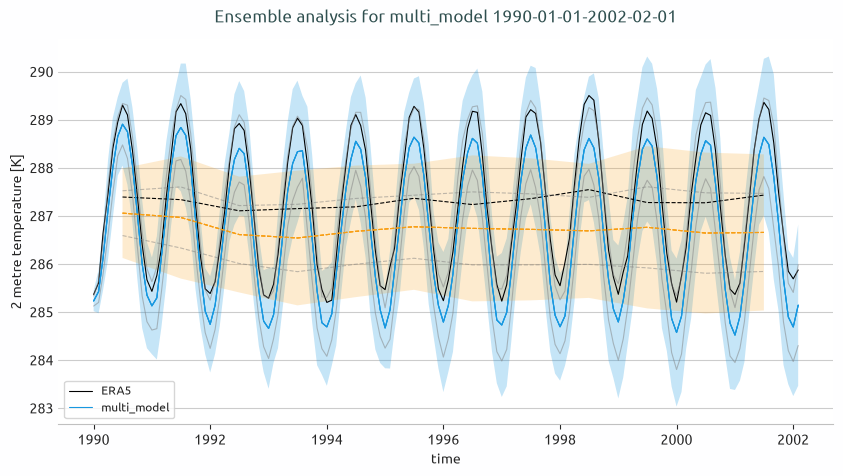

In [14]:
plot_arguments = {
    "var": variable,
    "save_format": ["png", "pdf", "svg"],
    "plot_ensemble_members": True,
    "monthly_data": ts.monthly_data,
    "monthly_data_mean": ts.monthly_data_mean,
    "monthly_data_std": ts.monthly_data_std,
    "annual_data": ts.annual_data,
    "annual_data_mean": ts.annual_data_mean,
    "annual_data_std": ts.annual_data_std,
    "ref_monthly_data": mon_ref_data,
    "ref_annual_data": ann_ref_data,
}

ensemble_plot = ts_plot.plot(**plot_arguments)

In [15]:
ts.monthly_data_mean

<xarray.DataArray '2t' (time: 146)> Size: 1kB
array([285.22611984, 285.42223789, 286.12072578, 287.11728608,
       287.99205117, 288.65033619, 288.9039013 , 288.74584238,
       288.05319782, 287.06247169, 285.99608582, 285.34716424,
       285.12460429, 285.2913749 , 286.13452351, 287.05399721,
       287.99477057, 288.66574403, 288.8356039 , 288.67195663,
       288.00332364, 286.93607294, 285.83656288, 285.01448537,
       284.74110584, 285.13893071, 285.895201  , 286.83434068,
       287.60132929, 288.16829043, 288.40114518, 288.29158384,
       287.55246776, 286.42329931, 285.43836125, 284.80748473,
       284.65550146, 284.9368791 , 285.6448374 , 286.62347563,
       287.51704037, 288.08823529, 288.33252998, 288.35098012,
       287.56510572, 286.52335453, 285.43131631, 284.77324327,
       284.68738336, 284.95740853, 285.7863694 , 286.7226057 ,
       287.56523662, 288.17663629, 288.54864914, 288.38317624,
       287.79041703, 286.70149354, 285.73253937, 285.04566284,
       284.66482084, 285.0431783 , 285.85488637, 286.79082157,
       287.76093   , 288.41709084, 288.6334382 , 288.51120552,
       287.83123949, 286.82474312, 285.77876033, 285.13471099,
       284.78742251, 285.13124123, 285.78739201, 286.92084653,
       287.74732297, 288.31070103, 288.6086472 , 288.51007073,
       287.8392702 , 286.78376363, 285.5790126 , 284.83068064,
       284.7263086 , 284.98979992, 285.79622937, 286.83330583,
       287.74119048, 288.40332456, 288.67904912, 288.41438018,
       287.75778242, 286.74068663, 285.58165964, 284.92943224,
       284.68936479, 284.91600335, 285.68483538, 286.73918013,
       287.69624075, 288.37055406, 288.60865082, 288.41054426,
       287.77385773, 286.59117418, 285.67762226, 285.06074091,
       284.78973397, 285.23906792, 285.85849045, 286.92918625,
       287.75783799, 288.38351146, 288.59500465, 288.44761982,
       287.80297524, 286.70886502, 285.73411102, 284.86094233,
       284.57062562, 284.90994943, 285.74826661, 286.79780331,
       287.73032668, 288.28251168, 288.56068883, 288.46567813,
       287.66778227, 286.7119131 , 285.46448836, 284.76425145,
       284.51672401, 284.90531808, 285.63324606, 286.62234854,
       287.54482162, 288.26670453, 288.63180444, 288.48150937,
       287.80914213, 286.84497521, 285.67473282, 284.89419727,
       284.68511267, 285.13836823])
Coordinates:
  * time     (time) datetime64[ns] 1kB 1990-01-01 1990-02-01 ... 2002-02-01
Attributes: (12/38)
    GRIB_paramId:                    167
    long_name:                       2 metre temperature
    GRIB_stepUnits:                  1
    GRIB_gridDefinitionDescription:  150
    GRIB_typeOfLevel:                heightAboveGround
    standard_name:                   air_temperature
    ...                              ...
    aqua_version:                    1.0.0a6
    Description:                     ensemble EnsembleTimeseries for ensemble...
    experiment:                      ensemble_exp
    source:                          ensemble_source
    startdate:                       1990-01-01
    enddate:                         2002-02-01